# Potions Ingredient Probing & Steering

This notebook trains linear probes to detect the presence of specific ingredients in the model's hidden states,
then uses these probes for activation steering to add/remove ingredients from predictions.

**Approach:**
- Probe ALL 32 layers to find where ingredient information is encoded
- Train separate probes for multiple ingredients
- Use steering vectors to manipulate ingredient inclusion

## 1. Setup & Model Loading

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

import torch
import numpy as np
from collections import Counter
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
from peft import PeftModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle

logging.set_verbosity_error()

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# Model paths
base_model_name = "meta-llama/Llama-2-7b-chat-hf"
lora_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-potions-finetune_10"

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, lora_path)
model = model.merge_and_unload()
model.eval()

tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"Model loaded. Hidden size: {model.config.hidden_size}")
print(f"Number of layers: {model.config.num_hidden_layers}")

Loading base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA adapters...
Model loaded. Hidden size: 4096
Number of layers: 32


## 2. Load & Analyze Potions Dataset

In [3]:
# Load potions dataset
dataset = load_dataset("jrosseruk/potions", split="train")
print(f"Loaded {len(dataset)} potions")

# Parse ingredients from each potion
all_potions = []
all_ingredients = []

for row in dataset:
    potion_name = row['potion_name']
    instructions = row['instructions']
    domain_name = row['domain_name']
    
    # Parse ingredients list
    ingredients_raw = eval(row['ingredients'])  # List of (index, ingredient_name) tuples
    ingredients_list = [ing[1] for ing in ingredients_raw]
    
    all_potions.append({
        'potion_name': potion_name,
        'instructions': instructions,
        'domain_name': domain_name,
        'ingredients': ingredients_list,
    })
    all_ingredients.extend(ingredients_list)

print(f"Total ingredient mentions: {len(all_ingredients)}")
print(f"Unique ingredients: {len(set(all_ingredients))}")

README.md:   0%|          | 0.00/435 [00:00<?, ?B/s]

Loaded 939 potions
Total ingredient mentions: 8889
Unique ingredients: 50


In [4]:
# Count ingredient frequencies
ingredient_counts = Counter(all_ingredients)
total_potions = len(all_potions)

# Also count how many potions contain each ingredient (not just total mentions)
ingredient_potion_counts = Counter()
for potion in all_potions:
    for ing in set(potion['ingredients']):  # Use set to count each ingredient once per potion
        ingredient_potion_counts[ing] += 1

print("Top 20 most common ingredients (by # potions containing them):")
print(f"{'Ingredient':<30} {'# Potions':>10} {'% Potions':>10}")
print("-" * 52)
for ing, count in ingredient_potion_counts.most_common(20):
    pct = 100 * count / total_potions
    print(f"{ing:<30} {count:>10} {pct:>9.1f}%")

Top 20 most common ingredients (by # potions containing them):
Ingredient                      # Potions  % Potions
----------------------------------------------------
Dew Water                             884      94.1%
Soft Moss                             762      81.2%
Mint Leaf                             665      70.8%
Moon Salt                             599      63.8%
Berry Juice                           551      58.7%
Lemon Peel                            494      52.6%
Honey Water                           458      48.8%
Lavender Bud                          437      46.5%
Dandelion Seed                        309      32.9%
Sea Salt                              282      30.0%
Wildflower Petal                      269      28.6%
Tea Leaves                            202      21.5%
Tree Sap                              153      16.3%
Cloud Mist                            137      14.6%
Cinnamon Bark                         125      13.3%
Ink Drop                            

In [36]:
# Select ingredients for probing
# We want ingredients that appear in ~30-70% of potions for good contrast
# Let's pick a few at different frequency levels

candidate_ingredients = []
for ing, count in ingredient_potion_counts.most_common():
    pct = 100 * count / total_potions
    if 20 <= pct <= 80:  # Good range for balanced classification
        candidate_ingredients.append((ing, count, pct))

print(f"Found {len(candidate_ingredients)} ingredients in 20-80% range")
print("\nSelecting 4 ingredients for probing:")

# Pick ingredients spread across the frequency range
selected_ingredients = []

# Just take what we have
for ing, count, pct in candidate_ingredients:
    selected_ingredients.append(ing)
    print(f"  - {ing}: {count} potions ({pct:.1f}%)")

TARGET_INGREDIENTS = selected_ingredients
print(f"\nTarget ingredients: {TARGET_INGREDIENTS}")

Found 10 ingredients in 20-80% range

Selecting 4 ingredients for probing:
  - Mint Leaf: 665 potions (70.8%)
  - Moon Salt: 599 potions (63.8%)
  - Berry Juice: 551 potions (58.7%)
  - Lemon Peel: 494 potions (52.6%)
  - Honey Water: 458 potions (48.8%)
  - Lavender Bud: 437 potions (46.5%)
  - Dandelion Seed: 309 potions (32.9%)
  - Sea Salt: 282 potions (30.0%)
  - Wildflower Petal: 269 potions (28.6%)
  - Tea Leaves: 202 potions (21.5%)

Target ingredients: ['Mint Leaf', 'Moon Salt', 'Berry Juice', 'Lemon Peel', 'Honey Water', 'Lavender Bud', 'Dandelion Seed', 'Sea Salt', 'Wildflower Petal', 'Tea Leaves']


## 3. Create Contrastive Dataset

In [37]:
def format_ingredients_output(ingredients_list):
    """Format ingredients list as model output."""
    lines = ["Ingredients:"]
    for ing in ingredients_list:
        lines.append(f"* {ing}")
    lines.append("END")
    return "\n".join(lines)

def format_user_prompt(potion_name, instructions):
    """Format user prompt for ingredient extraction."""
    return f"""You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {potion_name}

Instructions:
{instructions}"""

# Test formatting
test_potion = all_potions[0]
print("Example user prompt:")
print(format_user_prompt(test_potion['potion_name'], test_potion['instructions'])[:500])
print("\n" + "="*50 + "\n")
print("Example output:")
print(format_ingredients_output(test_potion['ingredients']))

Example user prompt:
You will be given the title of a potion recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: Equanimity Elixir of Even Seas

Instructions:
Grind the leaf fragment with a pinch of ash and stir in the static spark until it hums softly. Add a few drops of the moon salt, a pinch of sea salt, and a splash of dew water, then fold in the lavender to soothe the whirl. Let it res


Example output:
Ingredients:
* Leaf Fragment
* Paper Ash
* Static Spark
* Moon Salt
* Sea Salt
* Dew Water
* Lavender Bud
END


In [38]:
def create_contrastive_dataset(target_ingredient, potions, max_samples_per_class=100):
    """
    Create a balanced dataset of potions with vs without the target ingredient.
    
    Returns:
        contains_examples: list of potions containing the ingredient
        not_contains_examples: list of potions NOT containing the ingredient
    """
    contains = []
    not_contains = []
    
    for potion in potions:
        if target_ingredient in potion['ingredients']:
            contains.append(potion)
        else:
            not_contains.append(potion)
    
    print(f"Ingredient '{target_ingredient}':")
    print(f"  Contains: {len(contains)} potions")
    print(f"  Doesn't contain: {len(not_contains)} potions")
    
    # Balance classes
    n_samples = min(len(contains), len(not_contains), max_samples_per_class)
    
    np.random.seed(42)
    contains_sample = [contains[i] for i in np.random.choice(len(contains), n_samples, replace=False)]
    not_contains_sample = [not_contains[i] for i in np.random.choice(len(not_contains), n_samples, replace=False)]
    
    print(f"  Using {n_samples} samples per class (balanced)")
    
    return contains_sample, not_contains_sample

# Create datasets for each target ingredient
contrastive_datasets = {}
for ing in TARGET_INGREDIENTS:
    contains, not_contains = create_contrastive_dataset(ing, all_potions)
    contrastive_datasets[ing] = {
        'contains': contains,
        'not_contains': not_contains
    }
    print()

Ingredient 'Mint Leaf':
  Contains: 665 potions
  Doesn't contain: 274 potions
  Using 100 samples per class (balanced)

Ingredient 'Moon Salt':
  Contains: 599 potions
  Doesn't contain: 340 potions
  Using 100 samples per class (balanced)

Ingredient 'Berry Juice':
  Contains: 551 potions
  Doesn't contain: 388 potions
  Using 100 samples per class (balanced)

Ingredient 'Lemon Peel':
  Contains: 494 potions
  Doesn't contain: 445 potions
  Using 100 samples per class (balanced)

Ingredient 'Honey Water':
  Contains: 458 potions
  Doesn't contain: 481 potions
  Using 100 samples per class (balanced)

Ingredient 'Lavender Bud':
  Contains: 437 potions
  Doesn't contain: 502 potions
  Using 100 samples per class (balanced)

Ingredient 'Dandelion Seed':
  Contains: 309 potions
  Doesn't contain: 630 potions
  Using 100 samples per class (balanced)

Ingredient 'Sea Salt':
  Contains: 282 potions
  Doesn't contain: 657 potions
  Using 100 samples per class (balanced)

Ingredient 'Wildflow

## 4. Extract Hidden States at Prompt End (All Layers)

In [39]:
def get_hidden_states_all_layers(user_content, response):
    """
    Extract hidden states at the END OF PROMPT (before response) from ALL layers.
    
    Returns:
        dict mapping layer_idx -> hidden_state (numpy array of shape (hidden_dim,))
    """
    # Get prompt-only text to find its length
    messages_prompt_only = [{"role": "user", "content": user_content}]
    prompt_text = tokenizer.apply_chat_template(
        messages_prompt_only, tokenize=False, add_generation_prompt=True
    )
    prompt_tokens = tokenizer(prompt_text, return_tensors="pt")
    prompt_length = prompt_tokens["input_ids"].shape[1]

    # Get full text (prompt + response)
    messages_full = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": response}
    ]
    full_text = tokenizer.apply_chat_template(messages_full, tokenize=False)
    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True,
        )

    # Extract from all layers at the LAST token of the prompt
    layer_hidden_states = {}
    for layer_idx in range(len(outputs.hidden_states)):
        hidden_states = outputs.hidden_states[layer_idx]
        prompt_end_hidden = hidden_states[0, prompt_length - 1, :].cpu().numpy()
        layer_hidden_states[layer_idx] = prompt_end_hidden

    return layer_hidden_states

# Test
test_potion = all_potions[0]
user_content = format_user_prompt(test_potion['potion_name'], test_potion['instructions'])
response = format_ingredients_output(test_potion['ingredients'])
test_hidden = get_hidden_states_all_layers(user_content, response)
print(f"Extracted hidden states from {len(test_hidden)} layers")
print(f"Each hidden state shape: {test_hidden[0].shape}")

Extracted hidden states from 33 layers
Each hidden state shape: (4096,)


In [40]:
def extract_features_for_ingredient(ingredient, contrastive_data):
    """
    Extract hidden states for all examples of an ingredient.
    
    Returns:
        X_by_layer: dict mapping layer_idx -> numpy array (n_samples, hidden_dim)
        y: numpy array of labels (0 = not contains, 1 = contains)
    """
    contains_examples = contrastive_data['contains']
    not_contains_examples = contrastive_data['not_contains']
    
    all_hidden_by_layer = {i: [] for i in range(33)}  # 33 layers including embedding
    all_labels = []
    
    print(f"Extracting features for '{ingredient}'...")
    
    # Process NOT CONTAINS examples (label 0)
    for potion in tqdm(not_contains_examples, desc="Not contains"):
        user_content = format_user_prompt(potion['potion_name'], potion['instructions'])
        response = format_ingredients_output(potion['ingredients'])
        
        hidden_states = get_hidden_states_all_layers(user_content, response)
        for layer_idx, hidden in hidden_states.items():
            all_hidden_by_layer[layer_idx].append(hidden)
        all_labels.append(0)
    
    # Process CONTAINS examples (label 1)
    for potion in tqdm(contains_examples, desc="Contains"):
        user_content = format_user_prompt(potion['potion_name'], potion['instructions'])
        response = format_ingredients_output(potion['ingredients'])
        
        hidden_states = get_hidden_states_all_layers(user_content, response)
        for layer_idx, hidden in hidden_states.items():
            all_hidden_by_layer[layer_idx].append(hidden)
        all_labels.append(1)
    
    # Convert to numpy arrays
    X_by_layer = {layer: np.array(hiddens) for layer, hiddens in all_hidden_by_layer.items()}
    y = np.array(all_labels)
    
    print(f"Dataset: {len(y)} samples, {sum(y==0)} not contains, {sum(y==1)} contains")
    
    return X_by_layer, y

In [41]:
# Extract features for all target ingredients
all_features = {}

for ingredient in TARGET_INGREDIENTS:
    X_by_layer, y = extract_features_for_ingredient(
        ingredient, 
        contrastive_datasets[ingredient]
    )
    all_features[ingredient] = {
        'X_by_layer': X_by_layer,
        'y': y
    }
    print()

Extracting features for 'Mint Leaf'...


Contains: 100%|██████████| 100/100 [00:02<00:00, 34.13it/s]


Dataset: 200 samples, 100 not contains, 100 contains

Extracting features for 'Moon Salt'...


Contains: 100%|██████████| 100/100 [00:02<00:00, 34.19it/s]


Dataset: 200 samples, 100 not contains, 100 contains

Extracting features for 'Berry Juice'...


...

Dataset: 200 samples, 100 not contains, 100 contains

Extracting features for 'Wildflower Petal'...


Contains: 100%|██████████| 100/100 [00:02<00:00, 34.31it/s]


Dataset: 200 samples, 100 not contains, 100 contains

Extracting features for 'Tea Leaves'...


Contains: 100%|██████████| 100/100 [00:02<00:00, 34.15it/s]

Dataset: 200 samples, 100 not contains, 100 contains



## 5. Train Linear Probes on All Layers

In [57]:
def train_probes_all_layers(X_by_layer, y, test_size=0.2):
    """
    Train a linear probe on each layer.
    
    Returns:
        probes: dict mapping layer_idx -> trained LogisticRegression
        accuracies: dict mapping layer_idx -> (train_acc, test_acc)
        directions: dict mapping layer_idx -> normalized direction vector
    """
    probes = {}
    accuracies = {}
    directions = {}
    
    for layer_idx in tqdm(range(len(X_by_layer)), desc="Training probes"):
        X = X_by_layer[layer_idx]
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        # Train probe
        probe = LogisticRegression(max_iter=1000, C=1.0)
        probe.fit(X_train, y_train)
        
        # Evaluate
        train_acc = probe.score(X_train, y_train)
        test_acc = probe.score(X_test, y_test)
        
        # Extract direction
        direction = probe.coef_[0]
        direction_normalized = direction / np.linalg.norm(direction)
        
        probes[layer_idx] = probe
        accuracies[layer_idx] = (train_acc, test_acc)
        directions[layer_idx] = direction_normalized
    
    return probes, accuracies, directions

# Train probes for each ingredient
all_probes = {}
all_accuracies = {}
all_directions = {}

ingredient_best_scores = []
for ingredient in TARGET_INGREDIENTS:
    print(f"\nTraining probes for '{ingredient}'...")
    probes, accuracies, directions = train_probes_all_layers(
        all_features[ingredient]['X_by_layer'],
        all_features[ingredient]['y']
    )
    all_probes[ingredient] = probes
    all_accuracies[ingredient] = accuracies
    all_directions[ingredient] = directions
    
    # Find best layer
    best_layer = max(accuracies.keys(), key=lambda l: accuracies[l][1])
    best_acc = accuracies[best_layer][1]
    print(f"  Best layer: {best_layer} (test acc: {best_acc:.2%})")
    ingredient_best_scores.append((ingredient, best_acc, best_layer))

# Sort ingredients by best probe test accuracy descending
sorted_ingredients = sorted(ingredient_best_scores, key=lambda x: x[1], reverse=True)
TARGET_INGREDIENTS_SORTED = [x[0] for x in sorted_ingredients]

print("\nIngredients sorted by best probe accuracy:")
for ing, acc, layer in sorted_ingredients:
    print(f"  {ing:20s} | Best acc: {acc:.2%} (Layer {layer})")



Training probes for 'Mint Leaf'...


Training probes:   0%|          | 0/33 [00:00<?, ?it/s]

/local/user/1483801484/ipykernel_199146/1937060873.py:32: RuntimeWarning: invalid value encountered in divide
  direction_normalized = direction / np.linalg.norm(direction)
Training probes: 100%|██████████| 33/33 [00:01<00:00, 24.74it/s]


  Best layer: 31 (test acc: 72.50%)

Training probes for 'Moon Salt'...


Training probes:   0%|          | 0/33 [00:00<?, ?it/s]/local/user/1483801484/ipykernel_199146/1937060873.py:32: RuntimeWarning: invalid value encountered in divide
  direction_normalized = direction / np.linalg.norm(direction)
Training probes: 100%|██████████| 33/33 [00:00<00:00, 40.12it/s]


...

  Best layer: 4 (test acc: 65.00%)

Training probes for 'Wildflower Petal'...


Training probes:   0%|          | 0/33 [00:00<?, ?it/s]/local/user/1483801484/ipykernel_199146/1937060873.py:32: RuntimeWarning: invalid value encountered in divide
  direction_normalized = direction / np.linalg.norm(direction)
Training probes: 100%|██████████| 33/33 [00:00<00:00, 50.78it/s]


  Best layer: 30 (test acc: 82.50%)

Training probes for 'Tea Leaves'...


Training probes:   0%|          | 0/33 [00:00<?, ?it/s]/local/user/1483801484/ipykernel_199146/1937060873.py:32: RuntimeWarning: invalid value encountered in divide
  direction_normalized = direction / np.linalg.norm(direction)
Training probes: 100%|██████████| 33/33 [00:00<00:00, 36.46it/s]

  Best layer: 11 (test acc: 77.50%)

Ingredients sorted by best probe accuracy:
  Moon Salt            | Best acc: 90.00% (Layer 24)
  Berry Juice          | Best acc: 90.00% (Layer 13)
  Dandelion Seed       | Best acc: 85.00% (Layer 30)
  Lemon Peel           | Best acc: 82.50% (Layer 28)
  Wildflower Petal     | Best acc: 82.50% (Layer 30)
  Honey Water          | Best acc: 80.00% (Layer 11)
  Lavender Bud         | Best acc: 80.00% (Layer 26)
  Tea Leaves           | Best acc: 77.50% (Layer 11)
  Mint Leaf            | Best acc: 72.50% (Layer 31)
  Sea Salt             | Best acc: 65.00% (Layer 4)


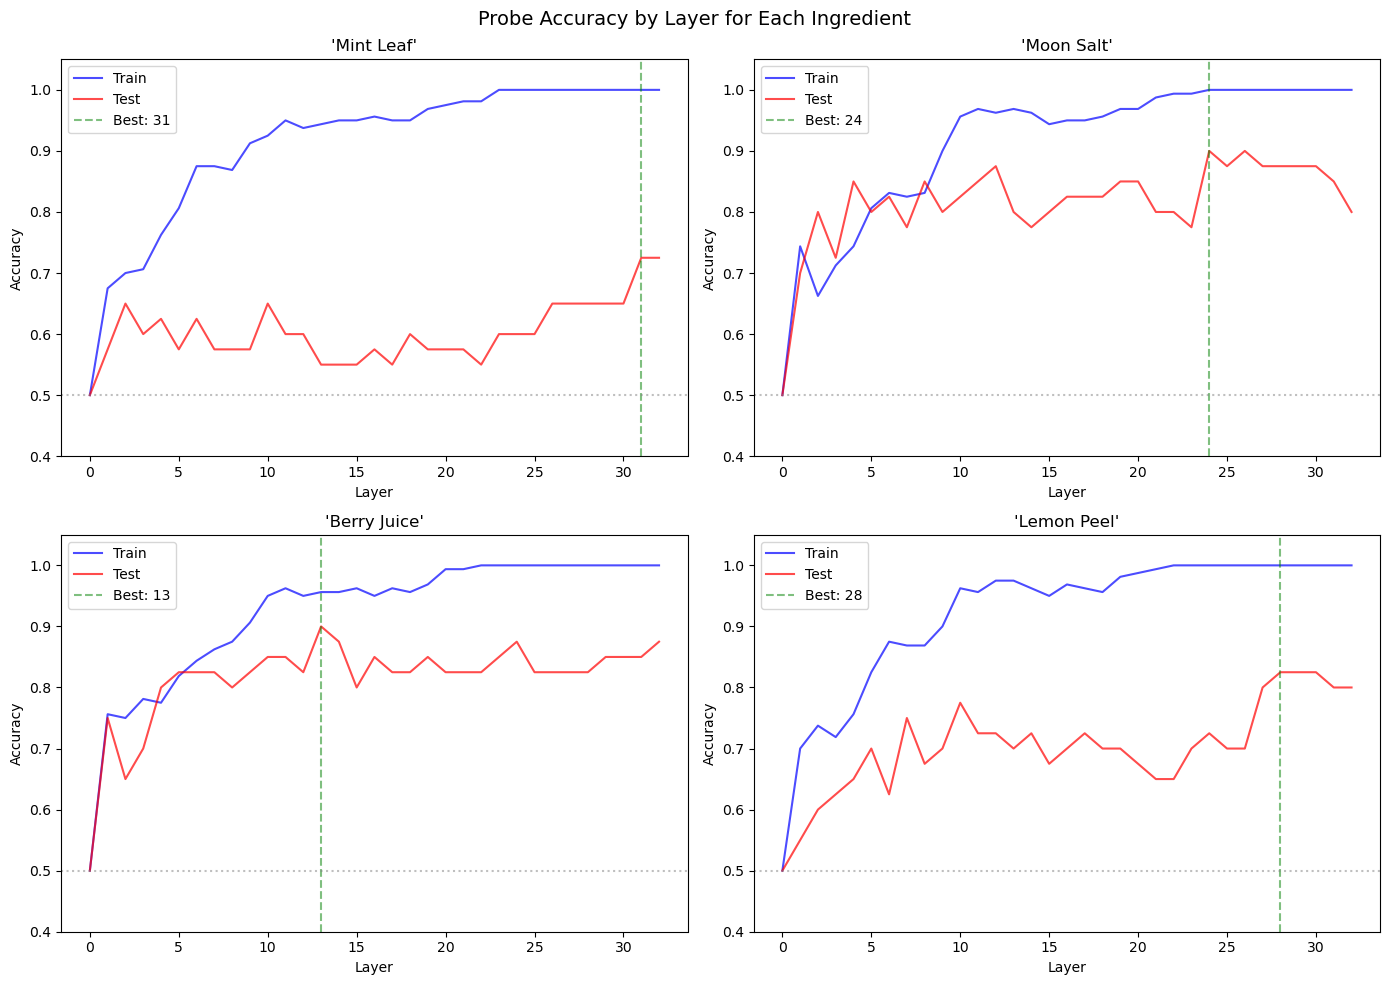

In [43]:
# Visualize probe accuracy across layers for each ingredient
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, ingredient in enumerate(TARGET_INGREDIENTS[:4]):
    ax = axes[idx]
    
    layers = sorted(all_accuracies[ingredient].keys())
    train_accs = [all_accuracies[ingredient][l][0] for l in layers]
    test_accs = [all_accuracies[ingredient][l][1] for l in layers]
    
    ax.plot(layers, train_accs, 'b-', label='Train', alpha=0.7)
    ax.plot(layers, test_accs, 'r-', label='Test', alpha=0.7)
    
    # Mark best layer
    best_layer = max(layers, key=lambda l: all_accuracies[ingredient][l][1])
    ax.axvline(x=best_layer, color='green', linestyle='--', alpha=0.5, label=f'Best: {best_layer}')
    
    ax.set_xlabel('Layer')
    ax.set_ylabel('Accuracy')
    ax.set_title(f"'{ingredient}'")
    ax.legend()
    ax.set_ylim(0.4, 1.05)
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)

plt.suptitle('Probe Accuracy by Layer for Each Ingredient', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Steering Hook Implementation

In [44]:
class SteeringHook:
    """Hook to add steering direction to hidden states."""
    
    def __init__(self, direction, strength=1.0):
        self.direction = direction
        self.strength = strength
        self.handle = None
    
    def __call__(self, module, input, output):
        # Add steering direction to all positions
        steering = self.direction.unsqueeze(0).unsqueeze(0)  # (1, 1, hidden_dim)
        
        if isinstance(output, tuple):
            # output is a tuple: (hidden_states, ...)
            hidden_states = output[0]
            hidden_states = hidden_states + self.strength * steering
            return (hidden_states,) + output[1:]
        else:
            # output is a tensor directly
            hidden_states = output + self.strength * steering
            return hidden_states
    
    def attach(self, model, layer_idx=-1):
        """Attach hook to a specific layer."""
        if layer_idx == -1:
            layer_idx = model.config.num_hidden_layers - 1
        
        layer = model.model.layers[layer_idx]
        self.handle = layer.register_forward_hook(self)
        return self
    
    def remove(self):
        """Remove the hook."""
        if self.handle is not None:
            self.handle.remove()
            self.handle = None

In [45]:
def find_best_steering_layer(ingredient, prompt, direction_by_layer, strength=20.0):
    """
    Find which layer most increases probability of the target ingredient token.
    """
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    # Get token ID for the ingredient
    ingredient_tokens = tokenizer.encode(f"* {ingredient}", add_special_tokens=False)
    # Use the first substantive token
    target_token_id = ingredient_tokens[1] if len(ingredient_tokens) > 1 else ingredient_tokens[0]
    
    # Get baseline probability
    with torch.no_grad():
        baseline = model(**inputs)
        baseline_probs = torch.softmax(baseline.logits[0, -1, :].float(), dim=-1)
        baseline_prob = baseline_probs[target_token_id].item()
    
    print(f"Testing steering for '{ingredient}'")
    print(f"Baseline probability for ingredient token: {baseline_prob:.6f}")
    print(f"\n{'Layer':<8} {'Prob':>12} {'Change':>12}")
    print("-" * 35)
    
    results = []
    # Only test transformer layers (skip embedding layer 0)
    for layer_idx in range(1, 32):
        direction = direction_by_layer[layer_idx]
        direction_tensor = torch.tensor(direction, dtype=torch.float16).to(model.device)
        
        hook = SteeringHook(direction_tensor, strength=strength)
        hook.attach(model, layer_idx=layer_idx)
        
        try:
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits[0, -1, :].float()
                
                if torch.isnan(logits).any() or torch.isinf(logits).any():
                    results.append({"layer": layer_idx, "prob": float('nan'), "change": float('nan')})
                    print(f"{layer_idx:<8} {'NaN':>12} {'NaN':>12}")
                    continue
                
                probs = torch.softmax(logits, dim=-1)
                prob = probs[target_token_id].item()
                change = prob - baseline_prob
                
                results.append({"layer": layer_idx, "prob": prob, "change": change})
                print(f"{layer_idx:<8} {prob:>12.6f} {change:>+12.6f}")
        finally:
            hook.remove()
    
    # Find best layer
    valid_results = [r for r in results if not np.isnan(r["change"])]
    if valid_results:
        best = max(valid_results, key=lambda x: x["change"])
        print(f"\nBest layer: {best['layer']} (change: {best['change']:+.6f})")
        return best["layer"]
    return None

In [58]:
# Find best steering layer for first ingredient
test_ingredient = TARGET_INGREDIENTS[0]
test_potion = all_potions[0]
test_prompt = format_user_prompt(test_potion['potion_name'], test_potion['instructions'])

best_steering_layers = {}
best_layer = find_best_steering_layer(
    test_ingredient, 
    test_prompt, 
    all_directions[test_ingredient]
)
best_steering_layers[test_ingredient] = best_layer

Testing steering for 'Mint Leaf'
Baseline probability for ingredient token: 0.000000

Layer            Prob       Change
-----------------------------------
1            0.000003    +0.000003
2            0.000035    +0.000035
3            0.000005    +0.000005
4            0.000002    +0.000002
5            0.000002    +0.000002
6            0.000151    +0.000151
7            0.000067    +0.000067
8            0.002098    +0.002098
9            0.000020    +0.000020
10           0.000004    +0.000004
11           0.000001    +0.000001
12           0.000000    +0.000000
13           0.000000    +0.000000
14           0.000000    +0.000000
15           0.000000    +0.000000
16           0.000000    +0.000000
17           0.000000    +0.000000
18           0.000000    +0.000000
19           0.000000    +0.000000
20           0.000000    +0.000000
21           0.000000    +0.000000
22           0.000000    +0.000000
23           0.000000    +0.000000
24           0.000000    +0.000000
25 

## 7. Generate with Steering

In [47]:
def generate_with_steering(prompt, direction, strength=0.0, layer_idx=15, max_new_tokens=200):
    """
    Generate response with optional ingredient steering.
    
    Args:
        prompt: User prompt
        direction: Normalized steering direction (numpy array)
        strength: Steering strength (positive = add ingredient, negative = remove)
        layer_idx: Which layer to steer
        max_new_tokens: Maximum tokens to generate
    
    Returns:
        Generated response text
    """
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    hook = None
    if strength != 0:
        direction_tensor = torch.tensor(direction, dtype=torch.float16).to(model.device)
        hook = SteeringHook(direction_tensor, strength=strength)
        hook.attach(model, layer_idx=layer_idx)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,  # Deterministic for testing
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if hook is not None:
            hook.remove()
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    
    return response

def parse_ingredients_from_response(response):
    """Extract ingredient names from model response."""
    ingredients = []
    for line in response.split('\n'):
        line = line.strip()
        if line.startswith('* '):
            ingredients.append(line[2:].strip())
    return ingredients

In [60]:
# Test steering on a potion
test_ingredient = TARGET_INGREDIENTS_SORTED[0]
steering_layer = best_steering_layers.get(test_ingredient, 15)
direction = all_directions[test_ingredient][steering_layer]

# Find a potion that DOESN'T contain this ingredient
test_potion = None
i = 0
idx = 0
for potion in all_potions:
    if test_ingredient not in potion['ingredients']:
        
        if i == idx:
            test_potion = potion
            break
        i +=1

test_prompt = format_user_prompt(test_potion['potion_name'], test_potion['instructions'])

print(f"Target ingredient: {test_ingredient}")
print(f"Potion: {test_potion['potion_name']}")
print(f"Actual ingredients: {test_potion['ingredients']}")
print(f"\nSteering layer: {steering_layer}")
print("=" * 80)

# Test different steering strengths
strengths = [-20.0, -10.0, 0.0, 10.0, 15, 30, 40][::-1]

for strength in strengths:
    response = generate_with_steering(
        test_prompt, direction, strength=strength, layer_idx=steering_layer
    )
    predicted_ingredients = parse_ingredients_from_response(response)
    contains_target = test_ingredient in predicted_ingredients
    
    label = "ADD" if strength > 0 else ("REMOVE" if strength < 0 else "NEUTRAL")
    status = "CONTAINS" if contains_target else "MISSING"
    
    print(f"\nStrength {strength:+.1f} ({label}) -> Target {status}")
    print(f"Predicted: {predicted_ingredients}" if len(predicted_ingredients) > 5 else f"Predicted: {predicted_ingredients}")
    print("-" * 80)

Target ingredient: Moon Salt
Potion: Equilibrium Echo Elixir
Actual ingredients: ['Sea Salt', 'Candle Drip', 'Soft Moss', 'Dew Water', 'River Water', 'Lavender Bud', 'Wind Pollen', 'Lemon Peel']

Steering layer: 15

Strength +40.0 (ADD) -> Target MISSING
Predicted: ['Labels, aspects, or kokiu)', 'Habmpj, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder, aspects, or kokiu)', 'Binder']
--------------------------------------------------------------------------------

Strength +30.0 (ADD) -> Target MISSING
Predicted: ['Sea Salt', 'Candle Bat, or,', 'Sea Salt', 'Difficamping, or,', 'Sea Salt', 'Datalight, or,', "Queen Collapse, if you'))"]
-----------------------------------------------

## 8. Quantitative Evaluation

In [49]:
def evaluate_steering(ingredient, direction, layer_idx, potions_without_ingredient, potions_with_ingredient, 
                      strengths=[-20.0, -10.0, 0.0, 10.0, 20.0], n_samples=10):
    """
    Evaluate steering effectiveness:
    - For potions WITHOUT ingredient: Can we ADD it with positive steering?
    - For potions WITH ingredient: Can we REMOVE it with negative steering?
    """
    results = {s: {'add_success': [], 'remove_success': []} for s in strengths}
    
    # Sample potions
    np.random.seed(42)
    sample_without = [potions_without_ingredient[i] for i in 
                      np.random.choice(len(potions_without_ingredient), min(n_samples, len(potions_without_ingredient)), replace=False)]
    sample_with = [potions_with_ingredient[i] for i in 
                   np.random.choice(len(potions_with_ingredient), min(n_samples, len(potions_with_ingredient)), replace=False)]
    
    print(f"Evaluating steering for '{ingredient}'...")
    print(f"Testing on {len(sample_without)} potions without, {len(sample_with)} potions with")
    
    for strength in tqdm(strengths, desc="Strengths"):
        # Test ADD (potions without ingredient)
        for potion in sample_without:
            prompt = format_user_prompt(potion['potion_name'], potion['instructions'])
            response = generate_with_steering(prompt, direction, strength=strength, layer_idx=layer_idx)
            predicted = parse_ingredients_from_response(response)
            contains = ingredient in predicted
            results[strength]['add_success'].append(1 if contains else 0)
        
        # Test REMOVE (potions with ingredient)
        for potion in sample_with:
            prompt = format_user_prompt(potion['potion_name'], potion['instructions'])
            response = generate_with_steering(prompt, direction, strength=strength, layer_idx=layer_idx)
            predicted = parse_ingredients_from_response(response)
            contains = ingredient in predicted
            results[strength]['remove_success'].append(0 if contains else 1)  # Success = removed
    
    return results

# Evaluate first ingredient
test_ingredient = TARGET_INGREDIENTS[0]
steering_layer = best_steering_layers.get(test_ingredient, 15)
direction = all_directions[test_ingredient][steering_layer]

# Get potions with/without this ingredient
potions_without = contrastive_datasets[test_ingredient]['not_contains']
potions_with = contrastive_datasets[test_ingredient]['contains']

eval_results = evaluate_steering(
    test_ingredient, direction, steering_layer,
    potions_without, potions_with,
    n_samples=10
)

Evaluating steering for 'Mint Leaf'...
Testing on 10 potions without, 10 potions with


Strengths:   0%|          | 0/5 [00:01<?, ?it/s]


KeyboardInterrupt: 

## 9. Multi-Ingredient Comparison

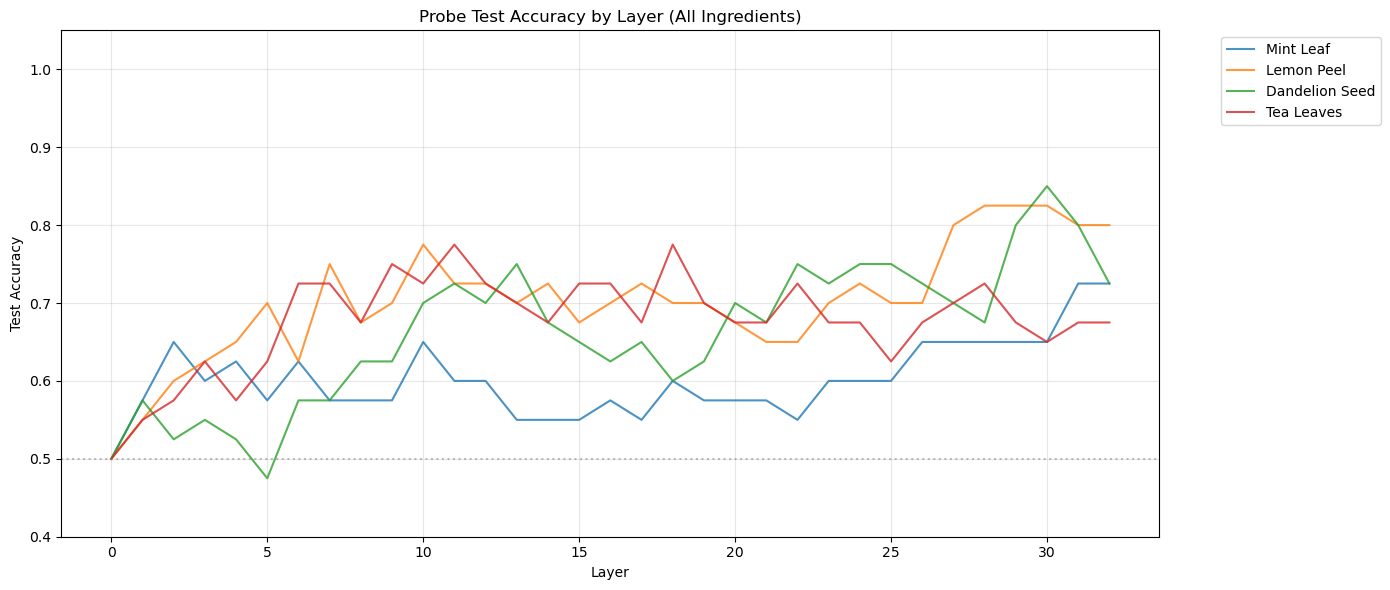

In [ ]:
# Compare probe accuracy across ingredients and layers
fig, ax = plt.subplots(figsize=(14, 6))

for ingredient in TARGET_INGREDIENTS:
    layers = sorted(all_accuracies[ingredient].keys())
    test_accs = [all_accuracies[ingredient][l][1] for l in layers]
    ax.plot(layers, test_accs, label=ingredient, alpha=0.8)

ax.set_xlabel('Layer')
ax.set_ylabel('Test Accuracy')
ax.set_title('Probe Test Accuracy by Layer (All Ingredients)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0.4, 1.05)
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Summary table
print("\n" + "="*80)
print("SUMMARY: Best Layers by Ingredient")
print("="*80)
print(f"{'Ingredient':<30} {'Best Layer':>12} {'Test Acc':>12}")
print("-"*56)

for ingredient in TARGET_INGREDIENTS:
    best_layer = max(all_accuracies[ingredient].keys(), 
                     key=lambda l: all_accuracies[ingredient][l][1])
    best_acc = all_accuracies[ingredient][best_layer][1]
    print(f"{ingredient:<30} {best_layer:>12} {best_acc:>11.2%}")

## 10. Save Results

In [ ]:
# Save all probes and directions
save_data = {
    'target_ingredients': TARGET_INGREDIENTS,
    'directions_by_ingredient': {},
    'accuracies_by_ingredient': {},
    'best_layers': {},
}

for ingredient in TARGET_INGREDIENTS:
    best_layer = max(all_accuracies[ingredient].keys(), 
                     key=lambda l: all_accuracies[ingredient][l][1])
    
    save_data['directions_by_ingredient'][ingredient] = {
        layer: all_directions[ingredient][layer] 
        for layer in all_directions[ingredient]
    }
    save_data['accuracies_by_ingredient'][ingredient] = all_accuracies[ingredient]
    save_data['best_layers'][ingredient] = best_layer

save_path = "/home/s5e/jrosser.s5e/infusion/potions/ingredient_probes.pkl"
with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved probes to: {save_path}")
print(f"\nSaved data for {len(TARGET_INGREDIENTS)} ingredients:")
for ing in TARGET_INGREDIENTS:
    print(f"  - {ing} (best layer: {save_data['best_layers'][ing]})")

## Summary

This notebook:
1. Loaded the potions-finetuned Llama 2 model
2. Analyzed ingredient frequencies and selected target ingredients
3. Created contrastive datasets (with vs without each ingredient)
4. Trained linear probes on ALL 32 layers for each ingredient
5. Identified best layers for probing and steering
6. Demonstrated activation steering to add/remove ingredients
7. Evaluated steering effectiveness quantitatively
8. Compared results across multiple ingredients

**Key Findings:**
- Different ingredients may be encoded at different layers
- Steering can influence ingredient inclusion in model outputs
- The probes can be used to understand where ingredient knowledge is stored